# Строим графики и считаем корреляции

In [23]:
import json
import numpy as np

from collections import defaultdict
from copy import deepcopy

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, kendalltau

sns.set_style('darkgrid')

In [3]:
n_iterations_grid = [2, 5, 14, 30]

for n_iterations in n_iterations_grid:
    with open(f'histories_finetuning_lr_fixed/history_{n_iterations}_iterations.json', 'r') as json_file:
        history_to_save = json.loads(json_file.read())

    finetuning_history = history_to_save["finetuning_history"]

    print(f'graph iterations: {n_iterations}\n')
    
    acc_orig = []

    acc_pruned_1 = []
    acc_pruned_2 = []
    acc_pruned_3 = []

    acc_fineturned_1 = []
    acc_fineturned_2 = []
    acc_fineturned_3 = []

    for finetuning_history_element in finetuning_history:
        acc_orig.append(finetuning_history_element['original_acc'])

        acc_pruned_1.append(finetuning_history_element['pruned_acc'][0])
        acc_pruned_2.append(finetuning_history_element['pruned_acc'][1])
        acc_pruned_3.append(finetuning_history_element['pruned_acc'][2])

        acc_fineturned_1.append(finetuning_history_element['fineturned_acc'][0])
        acc_fineturned_2.append(finetuning_history_element['fineturned_acc'][1])
        acc_fineturned_3.append(finetuning_history_element['fineturned_acc'][2])

    print(f'original acc:\t\t{np.mean(acc_orig):.4f}\n')
    print(f'top-1 pruned acc:\t{np.mean(acc_pruned_1):.4f}')
    print(f'top-1 fineturned acc:\t{np.mean(acc_fineturned_1):.4f}\n')
    print(f'top-2 pruned acc:\t{np.mean(acc_pruned_2):.4f}')
    print(f'top-2 fineturned acc:\t{np.mean(acc_fineturned_2):.4f}\n')
    print(f'top-3 pruned acc:\t{np.mean(acc_pruned_3):.4f}')
    print(f'top-3 fineturned acc:\t{np.mean(acc_fineturned_3):.4f}\n')

    print('='*30 + '\n')

graph iterations: 2

original acc:		0.9844

top-1 pruned acc:	0.9101
top-1 fineturned acc:	0.9101

top-2 pruned acc:	0.9198
top-2 fineturned acc:	0.9198

top-3 pruned acc:	0.8973
top-3 fineturned acc:	0.8976




FileNotFoundError: [Errno 2] No such file or directory: 'histories_finetuning_lr_fixed/history_5_iterations.json'

In [45]:
n_iterations_graph = 2

with open(f'../src/histories_bern/history_{n_iterations_graph}_iterations.json', 'r') as json_file:
    history_to_save = json.loads(json_file.read())

mnist_losses_history = history_to_save["mnist_losses_history"]
surrogate_losses_history = history_to_save["surrogate_losses_history"]
fcn_losses_history = history_to_save["fcn_losses_history"]
metric_results = history_to_save["metric_results"]
preds_results = history_to_save["preds_results"]
y_true_all = history_to_save["y_true_all"]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript back

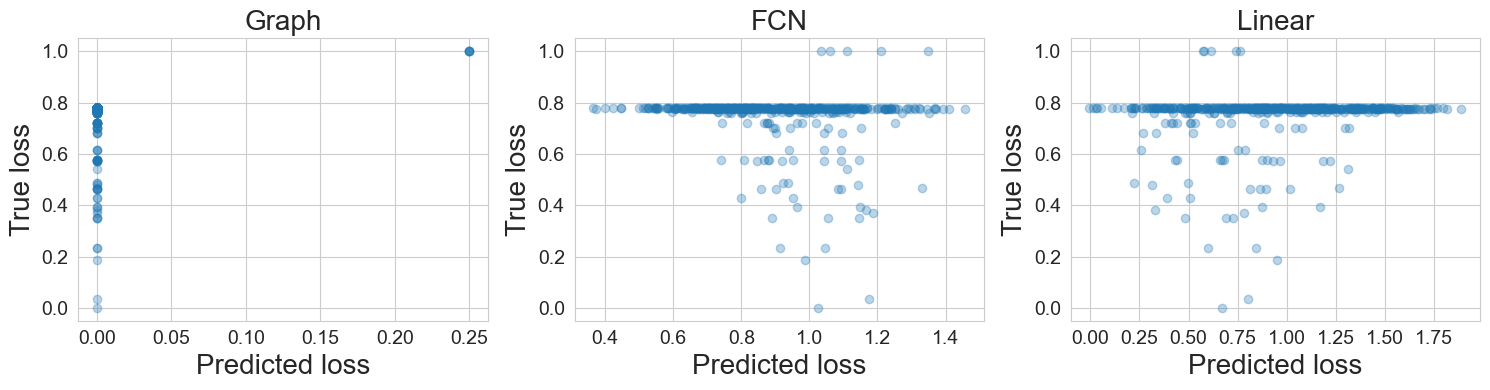

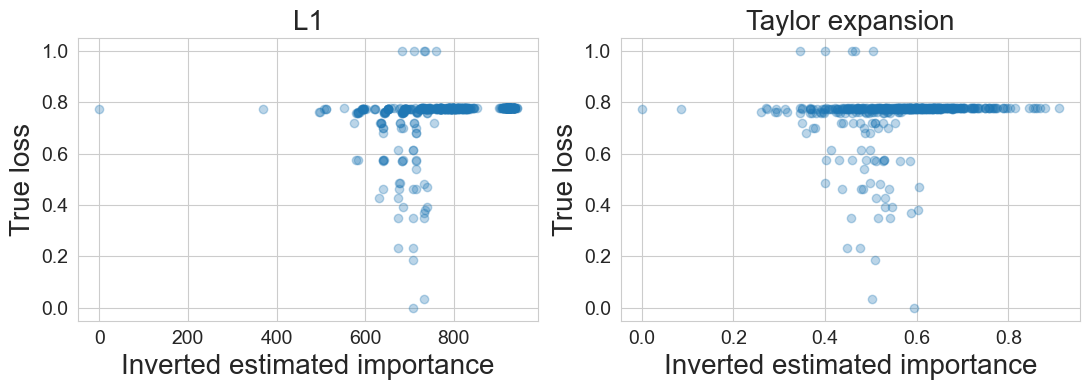

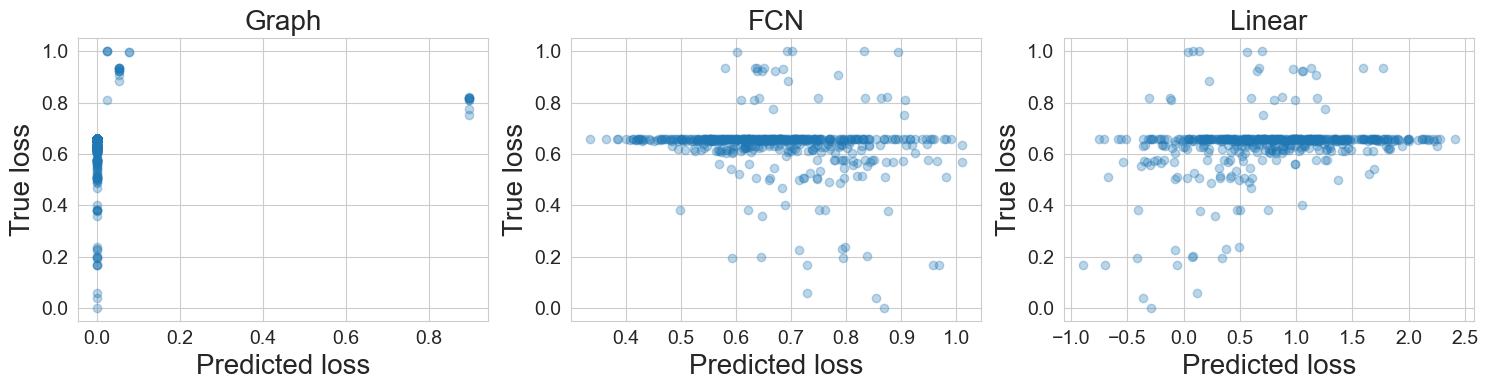

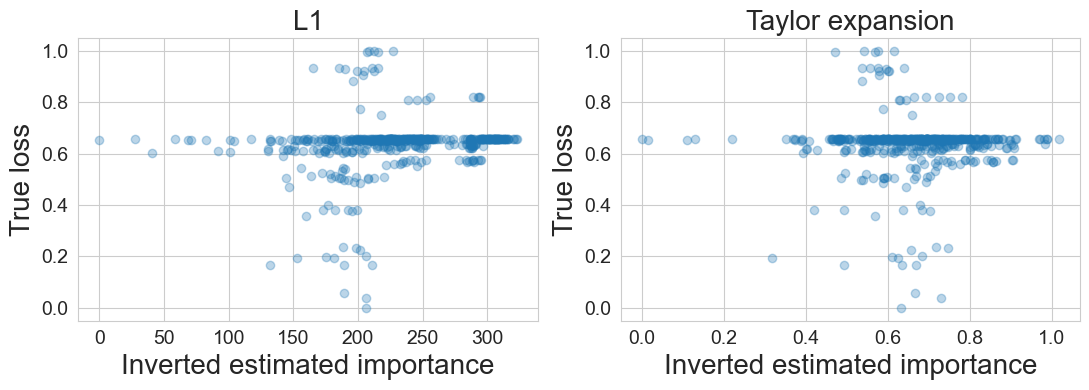

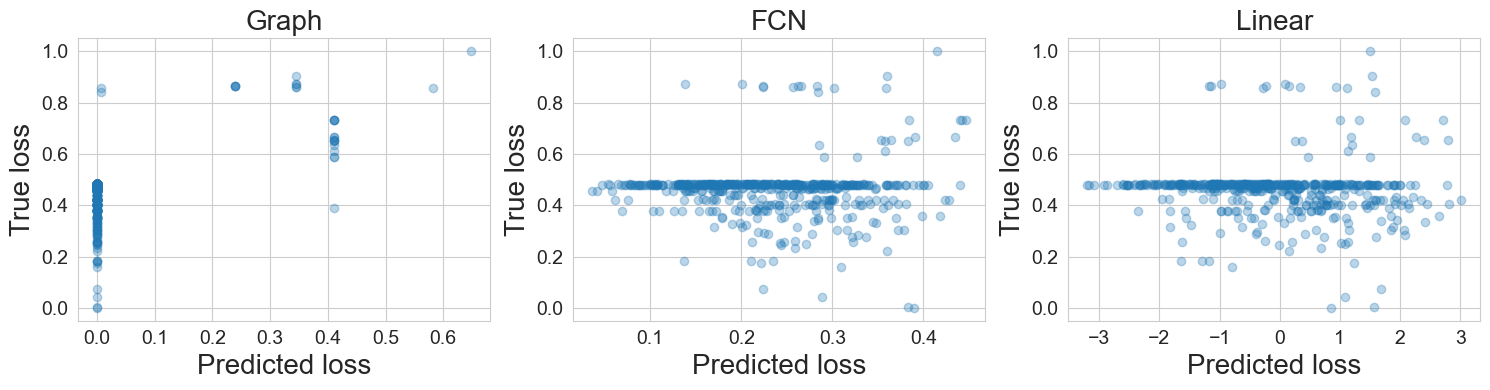

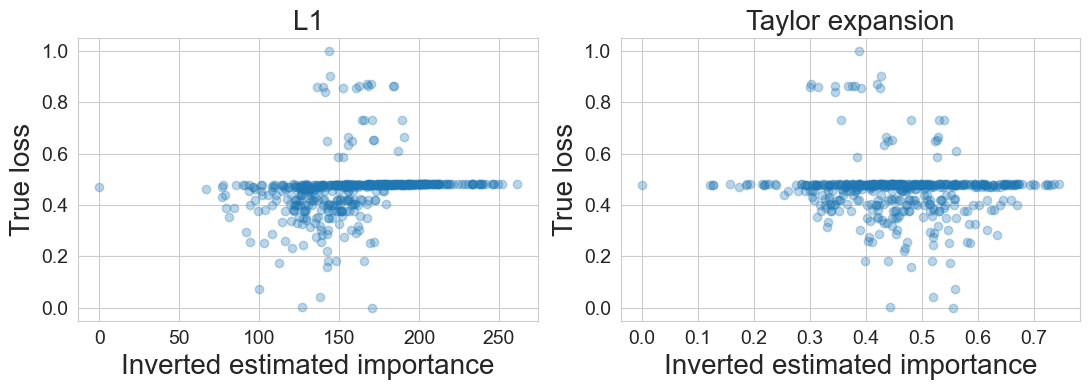

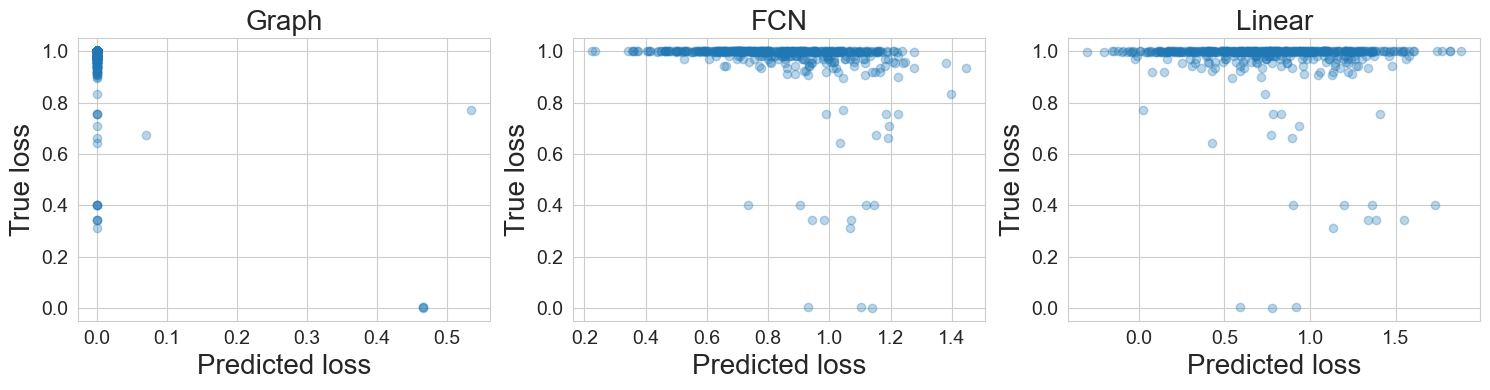

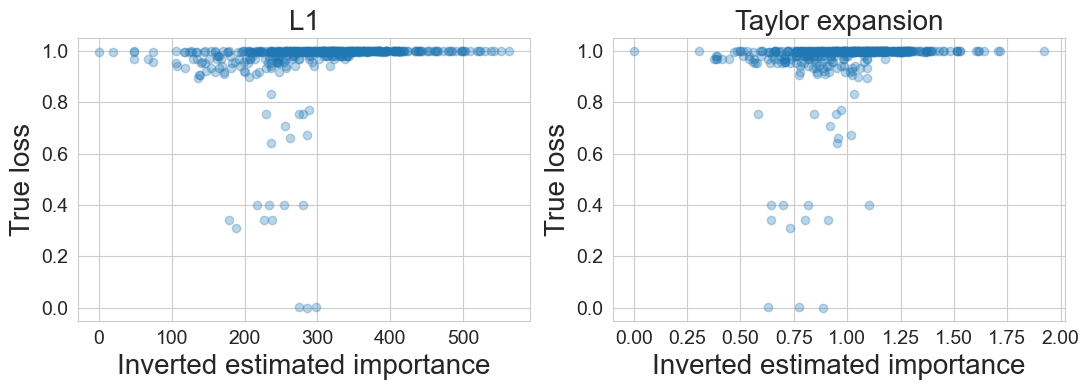

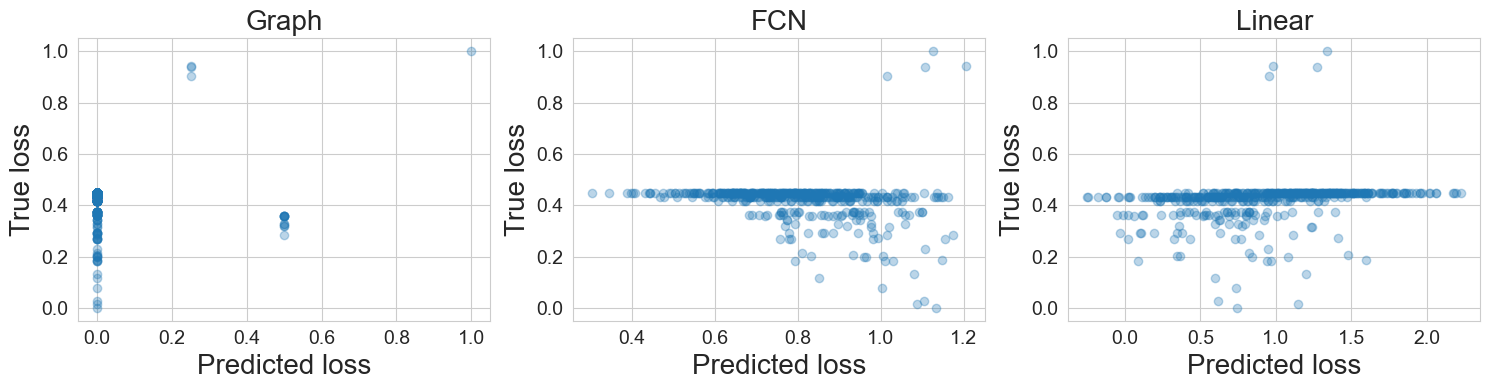

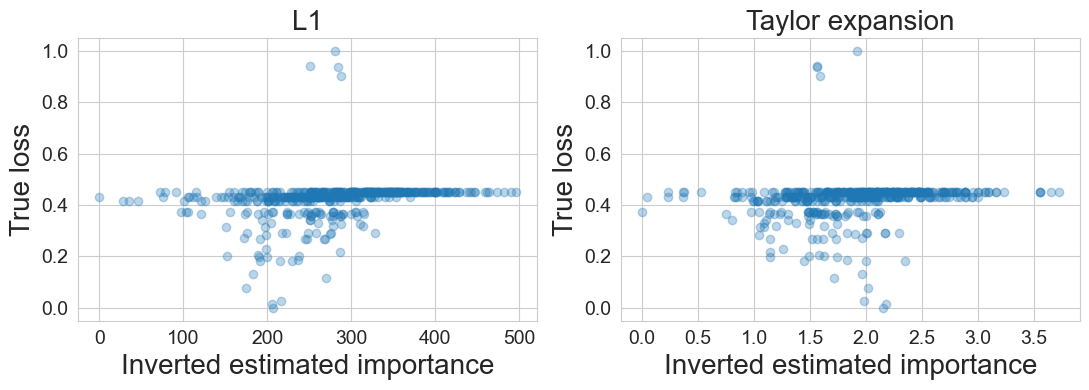

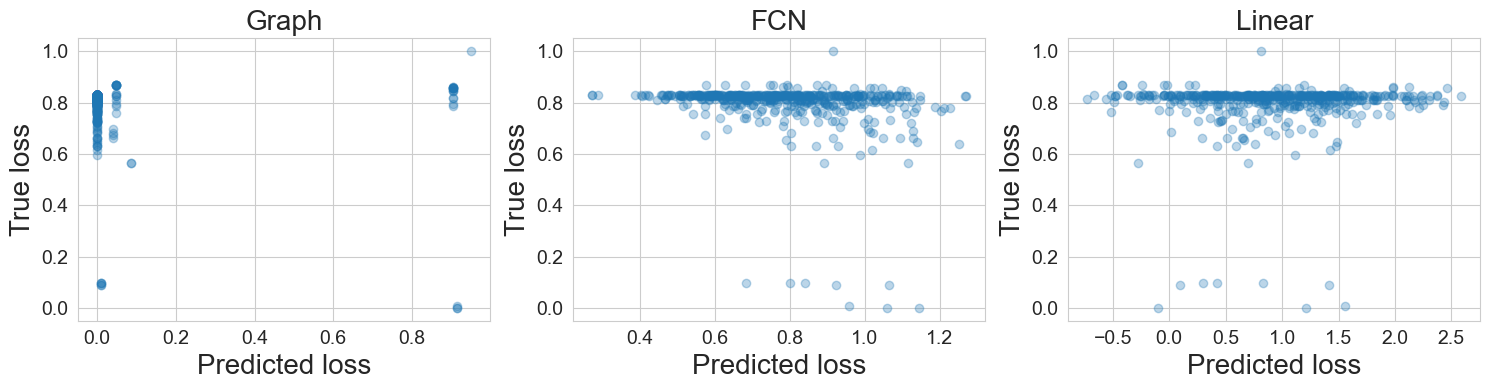

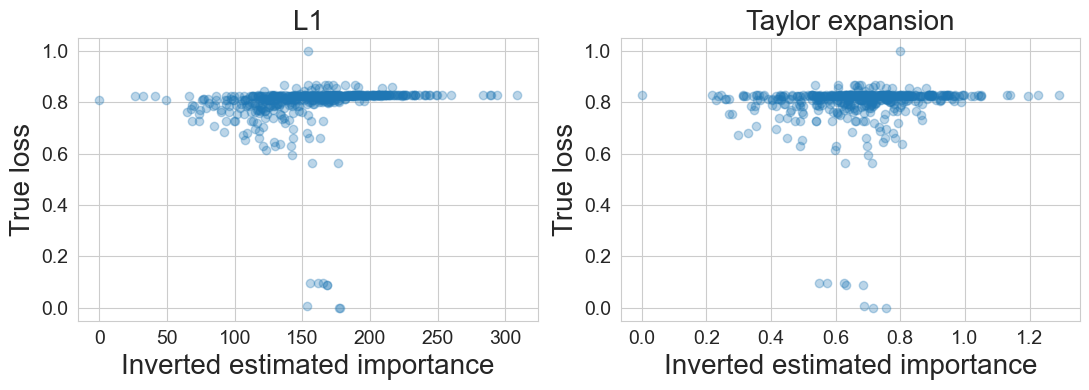

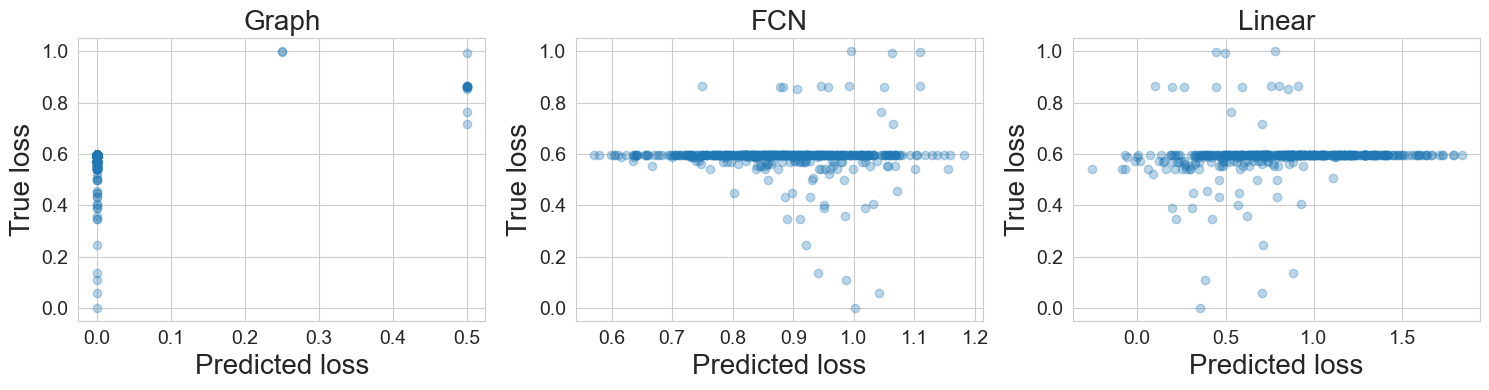

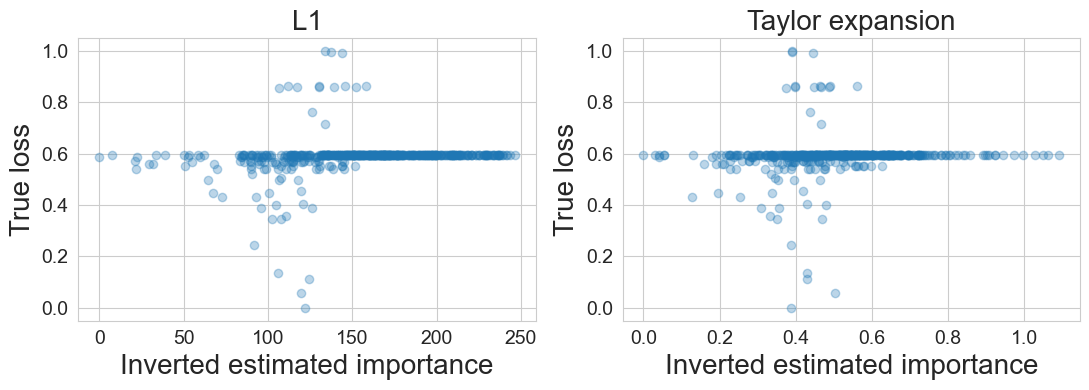

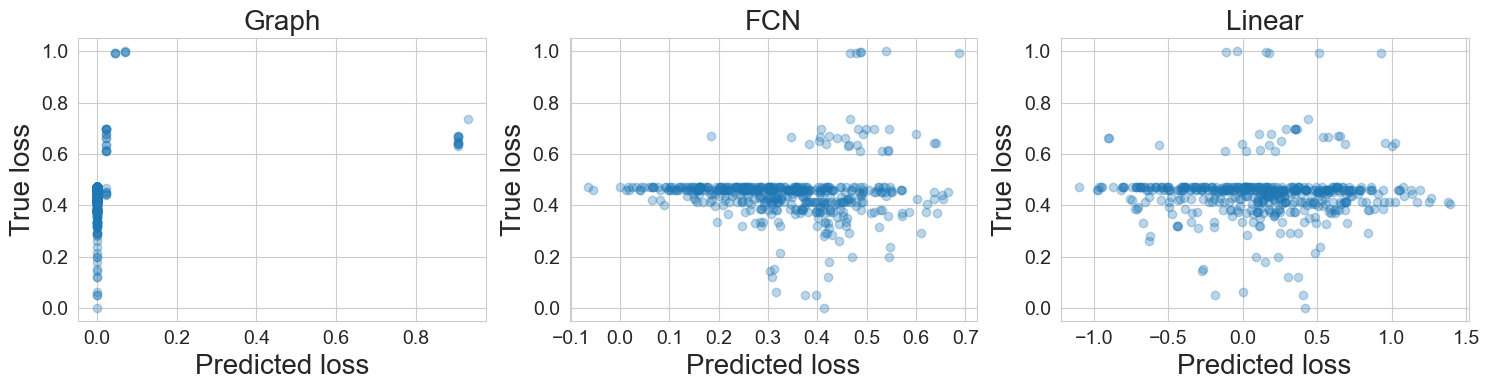

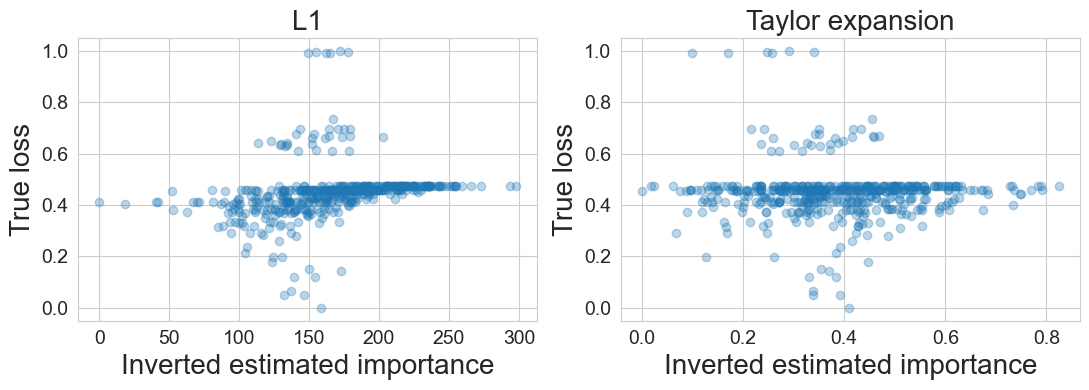

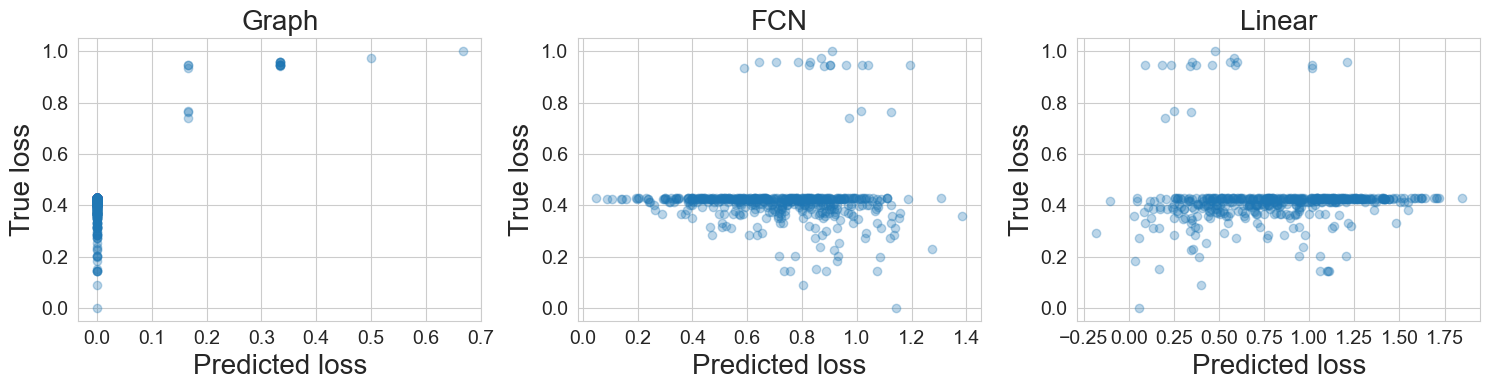

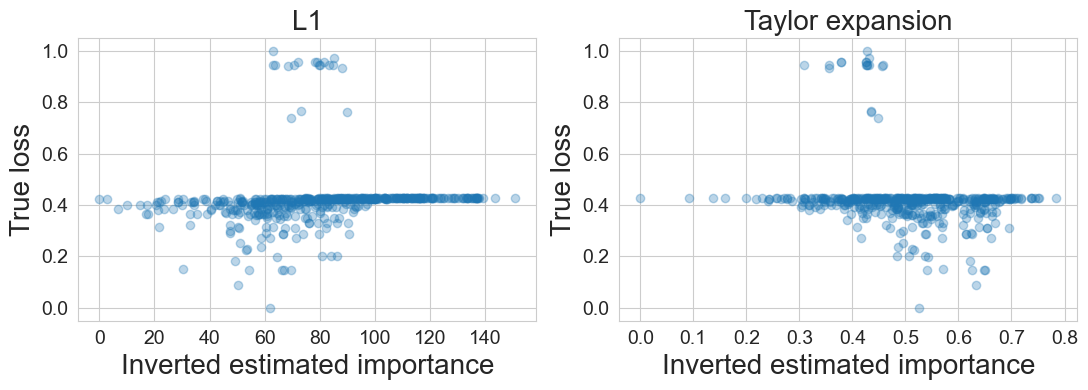

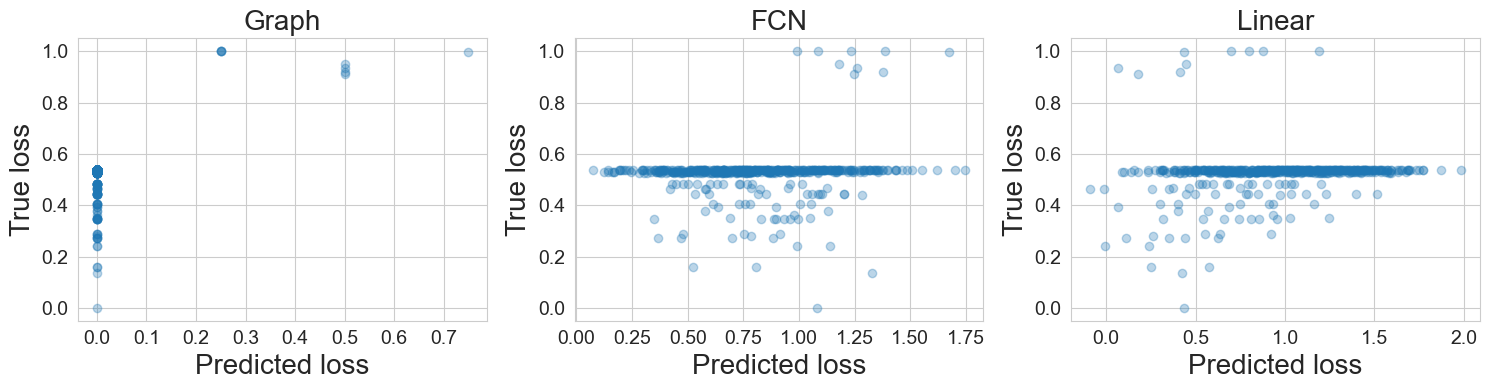

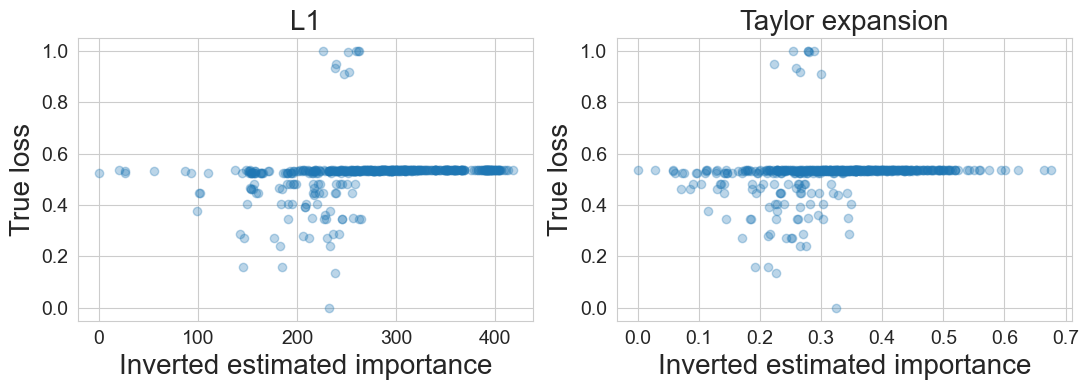

In [46]:
def update_metrics_and_plot(
    preds,
    y_true,
    model_name,
    subplot_idx,
    n_cols,
    xlabel,
):
    spearman_results[model_name].append(spearmanr(preds, y_true)[0])
    kendall_results[model_name].append(kendalltau(preds, y_true)[0])

    plt.subplot(1, n_cols, subplot_idx)
    plt.scatter(preds, y_true, alpha=0.3)

    plt.xlabel(xlabel, fontsize=20)
    plt.ylabel("True loss", fontsize=20)
    plt.title(
        "Taylor expansion" if model_name == "Molchanov" else model_name,
        fontsize=20,
    )
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)


spearman_results = defaultdict(list)
kendall_results = defaultdict(list)

model_items = list(preds_results.items())

with sns.axes_style("whitegrid"):
    for idx_experiment in range(len(mnist_losses_history)):
        y_true = y_true_all[idx_experiment]

        # --- Surrogate models ---
        plt.figure(figsize=(15, 4))

        for subplot_idx, (model_name, all_preds) in enumerate(model_items[:3], start=1):
            preds = all_preds[idx_experiment]

            update_metrics_and_plot(
                preds=preds,
                y_true=y_true,
                model_name=model_name,
                subplot_idx=subplot_idx,
                n_cols=3,
                xlabel="Predicted loss",
            )

        plt.tight_layout()
        plt.savefig(
            f"../src/histories_bern/figs/graph_1_iter_{n_iterations_graph}"
            f"_experiment_{idx_experiment + 1}.eps",
            format="eps",
        )
        # plt.close()

        # --- Importance-based methods ---
        plt.figure(figsize=(11, 4))

        for subplot_idx, (model_name, all_preds) in enumerate(model_items[3:], start=1):
            preds = np.asarray(all_preds[idx_experiment])
            preds = preds.max() - preds

            update_metrics_and_plot(
                preds=preds,
                y_true=y_true,
                model_name=model_name,
                subplot_idx=subplot_idx,
                n_cols=2,
                xlabel="Inverted estimated importance",
            )

        plt.tight_layout()
        plt.savefig(
            f"../src/histories_bern/figs/graph_2_iter_{n_iterations_graph}"
            f"_experiment_{idx_experiment + 1}.eps",
            format="eps",
        )
        # plt.close()

In [47]:
def format_metric(values):
    mean = np.mean(values)
    std = np.std(values, ddof=1)

    mean_str = f"{mean:.3f}"
    if mean < 0:
        mean_str = f"${mean_str}$"

    return f"{mean_str} $\\pm$ {std:.3f}"


def make_latex_table(results_by_group):
    group_names = list(results_by_group.keys())
    model_names = list(next(iter(results_by_group.values())).keys())

    # ищем лучший mean в каждом столбце
    best_mean = {}
    for group in group_names:
        best_mean[group] = max(
            np.mean(results_by_group[group][model])
            for model in model_names
        )

    lines = [
        r"\begin{tabular}{|r|" + "c|" * len(group_names) + r"}",
        r"\hline",
        r"\bfseries Model & "
        + " & ".join(group_names)
        + r" \\",
        r"\hline",
    ]

    for model in model_names:
        row = [("Taylor expansion" if model == "Molchanov" else model)]

        for group in group_names:
            values = results_by_group[group][model]

            mean = np.mean(values)
            std = np.std(values, ddof=1)

            value = f"{mean:.3f} $\\pm$ {std:.3f}"

            if mean < 0:
                value = f"${mean:.3f}$ $\\pm$ {std:.3f}"

            if np.isclose(mean, best_mean[group]):
                value = rf"\textbf{{{mean:.3f}}} $\pm$ {std:.3f}"

            row.append(value)

        lines.append(" & ".join(row) + r" \\")

    lines.extend([
        r"\hline",
        r"\end{tabular}",
    ])

    return "\n".join(lines)

In [48]:
kendall_results_2 = deepcopy(kendall_results)

In [35]:
all_spearman = {
    '10--15 edges': spearman_results_2,
    '20--40 edges': spearman_results_5,
    '50--100 edges': spearman_results_14,
    'more than 100 edges': spearman_results_30,
}

latex_table = make_latex_table(all_spearman)
print(latex_table)

\begin{tabular}{|r|c|c|c|c|}
\hline
\bfseries Model & 10--15 edges & 20--40 edges & 50--100 edges & more than 100 edges \\
\hline
Graph & 0.198 $\pm$ 0.212 & 0.336 $\pm$ 0.123 & 0.305 $\pm$ 0.173 & \textbf{0.396} $\pm$ 0.126 \\
FCN & $-0.174$ $\pm$ 0.201 & $-0.078$ $\pm$ 0.132 & $-0.138$ $\pm$ 0.091 & $-0.031$ $\pm$ 0.069 \\
Linear & 0.121 $\pm$ 0.259 & 0.005 $\pm$ 0.178 & 0.061 $\pm$ 0.089 & 0.061 $\pm$ 0.038 \\
L1 & \textbf{0.625} $\pm$ 0.087 & \textbf{0.497} $\pm$ 0.054 & \textbf{0.392} $\pm$ 0.131 & 0.266 $\pm$ 0.081 \\
Taylor expansion & 0.229 $\pm$ 0.242 & $-0.082$ $\pm$ 0.104 & $-0.094$ $\pm$ 0.155 & $-0.218$ $\pm$ 0.061 \\
\hline
\end{tabular}


In [49]:
all_kendall = {
    '10--15 edges': kendall_results_2,
    '20--40 edges': kendall_results_5,
    '50--100 edges': kendall_results_14,
    'more than 100 edges': kendall_results_30,
}

latex_table = make_latex_table(all_kendall)
print(latex_table)

\begin{tabular}{|r|c|c|c|c|}
\hline
\bfseries Model & 10--15 edges & 20--40 edges & 50--100 edges & more than 100 edges \\
\hline
Graph & 0.170 $\pm$ 0.186 & 0.273 $\pm$ 0.099 & 0.244 $\pm$ 0.137 & \textbf{0.315} $\pm$ 0.101 \\
FCN & $-0.130$ $\pm$ 0.152 & $-0.054$ $\pm$ 0.091 & $-0.093$ $\pm$ 0.062 & $-0.021$ $\pm$ 0.047 \\
Linear & 0.094 $\pm$ 0.192 & 0.004 $\pm$ 0.121 & 0.040 $\pm$ 0.060 & 0.041 $\pm$ 0.025 \\
L1 & \textbf{0.470} $\pm$ 0.076 & \textbf{0.350} $\pm$ 0.042 & \textbf{0.272} $\pm$ 0.094 & 0.183 $\pm$ 0.056 \\
Taylor expansion & 0.173 $\pm$ 0.184 & $-0.055$ $\pm$ 0.070 & $-0.062$ $\pm$ 0.103 & $-0.146$ $\pm$ 0.042 \\
\hline
\end{tabular}
